In [31]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
import h5py
sys.path.append('../')
import analysis_utils as utils
utils.load_plotting_setting()

from matplotlib.ticker import LogLocator, NullFormatter, MultipleLocator

sys.path.append('../upper/')
import upper

## Checked the projected DM rate

Text(0, 0.5, '$dR / dq_z$ (Counts/keV/s)')

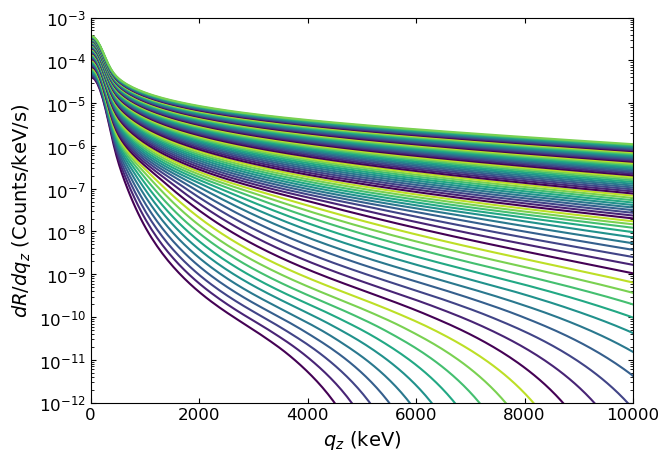

In [32]:
cmap = plt.colormaps.get_cmap('viridis')
colors = cmap(np.linspace(0, 0.9, 10))

drdqzn_1ev_file = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/dm_rate/drdqz_100mevthr_nanosphere_8.30e-02_coarse_ampdepsigma_1e+00.npz'
drdqzn_1ev = np.load(drdqzn_1ev_file)

q_kev = drdqzn_1ev['bc_kev']
drdqzn = drdqzn_1ev['drdqzn']
mx = drdqzn_1ev['mx_list']
alpha = drdqzn_1ev['alpha_list']

i_mx = 30
for i in range(0, 79):
    plt.plot(q_kev, drdqzn[i_mx, i], color=colors[(i) % 10])

plt.xlim(0, 10000)
plt.ylim(1e-12, 1e-3)
plt.yscale('log')

plt.xlabel('$q_z$ (keV)')
plt.ylabel('$dR / dq_z$ (Counts/keV/s)')

## Optimum interval alpha limits

In [61]:
def get_all_alpha_limits(sphere, datasets, mphi_lists, minlim=False, lowthr=False):

    mx_list = [[], []]
    alpha_lims = [[], []]
    for i, dataset in enumerate(datasets):
        for mphi in mphi_lists[i]:
            if mphi == 0:
                mphi_prefix = 'massless'
            else:
                mphi_prefix = f'{mphi:.0e}'

            if sphere == 'sphere_combined' :
                if minlim is True:
                    file = fr'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/alpha_lim_optimum/alpha_lim_{sphere}_minlim_{dataset}_{mphi_prefix}.npz'
                elif lowthr is True:
                    file = fr'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/alpha_lim_optimum/alpha_lim_{sphere}_{dataset}_{mphi_prefix}_1_25mevthr.npz'
                else:
                    file = fr'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/alpha_lim_optimum/alpha_lim_{sphere}_{dataset}_{mphi_prefix}.npz'
            else:
                file = fr'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/alpha_lim_optimum/alpha_lim_{sphere}_{dataset}_{mphi_prefix}.npz'

            npz_file = np.load(file)

            mx = npz_file['mx_gev']
            alpha_lim = npz_file['alpha_lim']

            mx_list[i].append(mx)
            alpha_lims[i].append(alpha_lim)

    # Mx for 10, 1, 0.1, 0 eV
    mx_list_ret = [mx_list[0][0], np.concatenate([mx_list[0][1], mx_list[1][0]]), np.concatenate([mx_list[0][2], mx_list[1][1]]), np.concatenate([mx_list[0][3], mx_list[1][2]])]
    alpha_lims_ret = [alpha_lims[0][0], np.concatenate([alpha_lims[0][1], alpha_lims[1][0]]), np.concatenate([alpha_lims[0][2], alpha_lims[1][1]]), np.concatenate([alpha_lims[0][3], alpha_lims[1][2]])]

    return mx_list_ret, alpha_lims_ret

def plot_alpha_lims(ax, mxs, alpha_lims):
    colors = ['#292f56', '#006290', '#0097a3', '#00cf97', '#acfa70']

    for i, mx in enumerate(mxs):
        ax.plot(mx, alpha_lims[i], color=colors[i])

    ax.fill_between(mxs[3], alpha_lims[3], 5e-4, color=colors[3], alpha=0.2)
    ax.fill_between(mxs[2], alpha_lims[2], 5e-4, color=colors[2], alpha=0.2)
    ax.fill_between(mxs[1], alpha_lims[1], 5e-4, color=colors[1], alpha=0.2)
    ax.fill_between(mxs[0], alpha_lims[0], 5e-4, color=colors[0], alpha=0.2)

    return ax

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'Single neutron coupling, $\\alpha_n$')

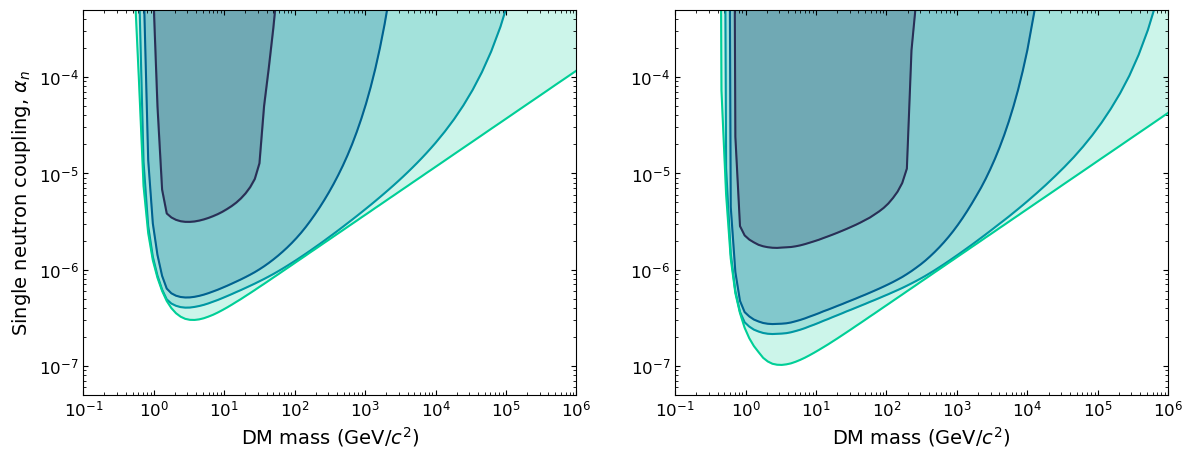

In [34]:
mxs_0, alpha_lims_0 = get_all_alpha_limits('sphere_20241202', ['coarse', 'coarse_extended_right'], [[10, 1, 0.1, 0], [1, 0.1, 0]])
mxs_1, alpha_lims_1 = get_all_alpha_limits('sphere_20250103', ['coarse', 'coarse_extended_right'], [[10, 1, 0.1, 0], [1, 0.1, 0]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0] = plot_alpha_lims(axes[0], mxs_0, alpha_lims_0)
axes[1] = plot_alpha_lims(axes[1], mxs_1, alpha_lims_1)

for ax in axes:
    ax.set_xlim(1e-1, 1e6)
    ax.set_ylim(5e-8, 5e-4)
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'DM mass (GeV/$c^2$)')
    
axes[1].legend(frameon=False)
axes[0].set_ylabel(r'Single neutron coupling, $\alpha_n$')


#### Combined alpha limits

In [35]:
def get_masked_usphere_lim(usphere_lim, nanosphere_lim):
    mask = usphere_lim > nanosphere_lim
    masked_usphere_lim = np.where(mask, np.nan, usphere_lim)

    return masked_usphere_lim

In [36]:
# Load the microsphere limits
usphere_lim_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/other_limits/microsphere_limits_2020'
mphi_usphere = [1, 0.1, 0.01, 0]

mx_usphere, alpha_lim_usphere = [], []
for mphi in mphi_usphere:
    npz_file = np.load(f'{usphere_lim_dir}/limits_mphi_{mphi:.0e}_nugg_frac_1.00e+00.npz')
    mx_usphere.append(npz_file['x'])
    alpha_lim_usphere.append(npz_file['y'])

In [62]:
mxs_c, alpha_lims_c = get_all_alpha_limits('sphere_combined', ['coarse', 'coarse_extended_right'], [[10, 1, 0.1, 0], [1, 0.1, 0]], minlim=False, lowthr=False)
mxs_cl, alpha_lims_cl = get_all_alpha_limits('sphere_combined', ['coarse', 'coarse_extended_right'], [[10, 1, 0.1, 0], [1, 0.1, 0]], minlim=False, lowthr=True)

(1e-07, 0.0005)

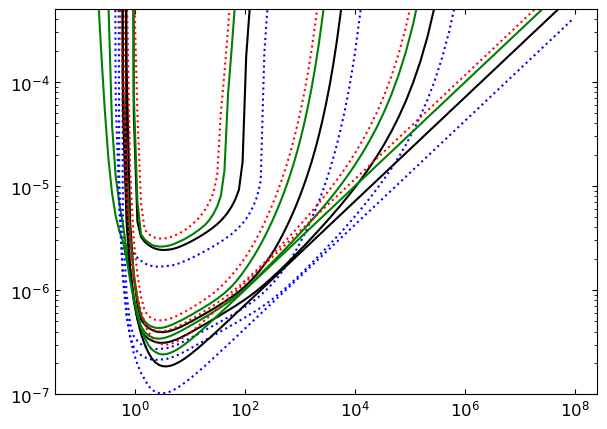

In [63]:
for i in range(4):
    plt.loglog(mxs_c[i], alpha_lims_c[i], 'k')
    plt.loglog(mxs_cl[i], alpha_lims_cl[i], 'g')

    plt.loglog(mxs_0[i], alpha_lims_0[i], 'r:')
    plt.loglog(mxs_1[i], alpha_lims_1[i], 'b:')

plt.ylim(1e-7, 5e-4)

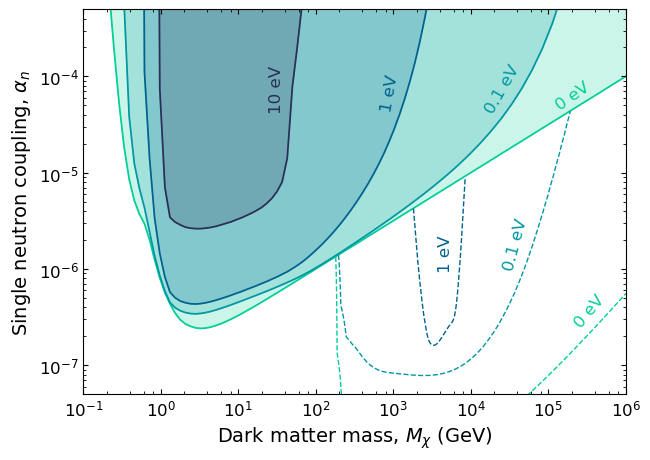

In [87]:
mxs_cl, alpha_lims_cl = get_all_alpha_limits('sphere_combined', ['coarse', 'coarse_extended_right'], [[10, 1, 0.1, 0], [1, 0.1, 0]], minlim=False, lowthr=True)

# Resample microsphere limits for plotting
mx_fine = np.logspace(1, 8, 5000)
alpha_lim_usphere_1ev = np.interp(mx_fine, mx_usphere[0], alpha_lim_usphere[0], left=np.nan, right=np.nan)
alpha_lim_usphere_0_1ev = np.interp(mx_fine, mx_usphere[1], alpha_lim_usphere[1], left=np.nan, right=np.nan)
alpha_lim_usphere_0ev = np.interp(mx_fine, mx_usphere[3], alpha_lim_usphere[3], left=np.nan, right=np.nan)

alpha_lim_combined_dm_0ev_fine = np.interp(mx_fine, mxs_cl[3], alpha_lims_cl[3], left=np.nan, right=np.nan)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
colors = ['#292f56', '#006290', '#0097a3', '#00cf97', '#acfa70']

ax.plot(mxs_cl[0], alpha_lims_cl[0], '-', color=colors[0], label=r'$m_\phi$ = 10 eV', linewidth=1.25)
ax.plot(mxs_cl[1], alpha_lims_cl[1], '-', color=colors[1], label=r'$m_\phi$ = 1 eV', linewidth=1.25)
ax.plot(mxs_cl[2], alpha_lims_cl[2], '-', color=colors[2], label=r'$m_\phi$ = 0.1 eV', linewidth=1.25)
ax.plot(mxs_cl[3], alpha_lims_cl[3], '-', color=colors[3], label=r'$m_\phi$ = 0 eV', linewidth=1.25, zorder=-5)

ax.plot(mx_fine, get_masked_usphere_lim(alpha_lim_usphere_1ev, alpha_lim_combined_dm_0ev_fine), '--', color=colors[1], alpha=1, linewidth=1, zorder=-5)
ax.plot(mx_fine, get_masked_usphere_lim(alpha_lim_usphere_0_1ev, alpha_lim_combined_dm_0ev_fine), '--', color=colors[2], alpha=1, linewidth=1, zorder=-5)
ax.plot(mx_fine, get_masked_usphere_lim(alpha_lim_usphere_0ev, alpha_lim_combined_dm_0ev_fine), '--', color=colors[3], alpha=1, linewidth=1, zorder=-5)

ax.fill_between(mxs_cl[3], alpha_lims_cl[3], 5e-4, color=colors[3], alpha=0.2)
ax.fill_between(mxs_cl[2], alpha_lims_cl[2], 5e-4, color=colors[2], alpha=0.2)
ax.fill_between(mxs_cl[1], alpha_lims_cl[1], 5e-4, color=colors[1], alpha=0.2)
ax.fill_between(mxs_cl[0], alpha_lims_cl[0], 5e-4, color=colors[0], alpha=0.2)

ax.text(1.15e5, 4.5e-5, '0 eV', color=colors[3], rotation=35, fontsize=12)
ax.text(1.4e4, 4.25e-5, '0.1 eV', color=colors[2], rotation=60, fontsize=12)
ax.text(6.5e2, 4.5e-5, '1 eV', color=colors[1], rotation=80, fontsize=12)
ax.text(2.5e1, 4.5e-5, '10 eV', color=colors[0], rotation=90, fontsize=12)

ax.text(2e5, 2.5e-7, '0 eV', color=colors[3], rotation=50, fontsize=12)
ax.text(2.5e4, 1e-6, '0.1 eV', color=colors[2], rotation=75, fontsize=12)
ax.text(3.75e3, 1e-6, '1 eV', color=colors[1], rotation=90, fontsize=12)

plt.xlim(1e-1, 1e6)
plt.ylim(5e-8, 5e-4)
plt.xscale('log')
plt.yscale('log')

locmaj = LogLocator(base=10, numticks=11) 
ax.xaxis.set_major_locator(locmaj)
locmin = LogLocator(base=10.0,subs=(0.2,0.4,0.6,0.8),numticks=11)
ax.xaxis.set_minor_locator(locmin)
ax.xaxis.set_minor_formatter(NullFormatter())

plt.xlabel(r'Dark matter mass, $M_\chi$ (GeV)')
plt.ylabel(r'Single neutron coupling, $\alpha_n$')

plt.savefig('../paper_plots/combined_alpha_limits.pdf', dpi=600)

## Composite dark matter limits

In [88]:
c = 3e5
c_cm = 3e10  # cm/s
v0 = 220 / c
mN = 1
q0 = v0 * 1

sub_component_frac = 1
def get_dm_xsec(mX, mchi, Eth, mN, nevts, target_mass, expos):
    """
    Approximate cross section limits for direct detection experiments
    
    Parameters:
    mX: DM mass in GeV
    mchi: DM constituent mass in GeV
    Eth: energy threshold in GeV
    mN: *nucleus* mass in GeV
    nevts: number of events to set the 95% CL limits
    target_mass: kg
    expos: exposure in seconds
    """
    
    A = 1.0 * mN ## number of nucleons
    mnuc = 1

    gtgx = 1
    rhoX = 0.3 * sub_component_frac ## GeV/cm^3

    NX = mX/mchi
    mu = (mX * mN)/(mX + mN)
    
    Rx = (9*np.pi/4 * mX/mchi**4)**(1/3)
    sig0 = NX**2 * gtgx**2 * mu**2

    nT = (target_mass * 1e3) / A * 6.02e23
    sigtot_lim = (nevts / (nT * expos)) / ( rhoX/mX * v0 * c_cm) # in cm^2

    ### Below is incorrect
    # sigXn12 = sigtot_lim * (8 * Eth * v0**2 * mnuc**3) / (A * q0**4)
    # sigXn3 = sigtot_lim * (64 * A * Rx**4 * v0**2 * mnuc**5 * Eth**3)/(3 * q0**4)
    # sigXtot = 1.0*sigXn12

    # gidx3 = mX > np.sqrt(2) * mchi/(9*np.pi) * (mchi**2/(mN * Eth))**(3/2)
    # sigXtot[gidx3] = sigXn3[gidx3]
    
    ### My implementation
    q_min = np.sqrt(2 * A * mnuc * Eth)
    q_max = np.min([2*mX*v0, 2*np.full_like(mX, mN)*v0], axis=0)
    
    mu_chi_n = (mX * mnuc) / (mX + mnuc)
    sigXtot = sigtot_lim * 4 * v0**2 * mu_chi_n**2 / ( A**2 * q0**4 * (1/(q_min**2) - 1/(q_max**2)) )
    sigXn3 = sigtot_lim * 8 * Rx**4 * v0**2 * mu_chi_n**2 / (3 * A**2 * q0**4 * (1/(q_min**6) - 1/(q_max**6)) )

    gidx3 = mX > np.sqrt(2) * mchi/(9*np.pi) * (mchi**2/(mN * Eth))**(3/2)
    sigXtot[gidx3] = sigXn3[gidx3]

    # When `q_min` > `q_max` will become negative
    # That means the maximum momentum transfer is below the detectable threshold
    sigXtot[sigXtot < 0] = np.nan
    
    return sigXtot

In [89]:
convert_factor = 0.3894e-27 / 1e-18  # 1 / eV^2 -> cm^2
mn_ev = 939.565e6                    # neutron mass (eV)

def get_sphere_sigma_n(mx, mphi, yn, yx_lim='unity', yx=None):    
    # Input mx in eV (array-like)
    # Note that we parametrize the cross section in a way slightly
    # different from the composite dm paper
    # -- there is a (small) factor of mediator mass squared
    # -- reference momentum transfer is chosen as v_dm * mn

    sig_n = np.empty_like(mx)
    if yx_lim == 'unity':
        yx = 1
    else:
        raise('Other ychi choices not implemented')
        
    # DM-neutron reduced mass
    mu_xn = mx * mn_ev / (mx + mn_ev)

    # Cross section in cm^2
    # `1e-3 * mu_xn` is the reference momentum transfer 
    # sig_n = convert_factor * yn**2 * yx**2 * mu_xn**2 / (4 * np.pi * (mphi**2 + (1e-3 * mx)**2)**2)
    # sig_n = convert_factor * yn**2 * yx**2 * mu_xn**2 / (4 * np.pi * ((1e-3 * mn_ev)**2)**2)
    sig_n = convert_factor * yn**2 * yx**2 * mu_xn**2 / (4 * np.pi * (mphi**2 + (1e-3 * mu_xn)**2)**2)

    return sig_n

In [90]:
fifth_force_lim = np.genfromtxt('../other_limits/fifth_force_lim_ev.csv', delimiter=' ', skip_header=1).T
n_xe_lim = np.genfromtxt('../other_limits/n_xe_yn_lim.csv', delimiter=',').T
stellar_cooling_lim = np.genfromtxt('../other_limits/stellar_cooling_yn_lim.csv', delimiter=',').T
sn1987a_lim = np.genfromtxt('../other_limits/sn1987a_yn_lim_lower.csv', delimiter=',').T

# DM mass in MeV
sidm_yx_lim     = np.genfromtxt('../other_limits/sidm_yx_lim.csv', delimiter=',').T
sidm_yx_lim[0]  = sidm_yx_lim[0] * 1e6  # Convert MeV to eV

def get_fifth_force_sigma_n(mx, mphi, lim='fifth_force', yx_lim='unity', Nx=1):
    # Input mx in eV (array-like)
    dat = None
    if lim == 'fifth_force':
        dat = fifth_force_lim
    elif lim == 'n_xe':
        dat = n_xe_lim
    elif lim == 'stellar_cooling':
        dat = stellar_cooling_lim
    elif lim == 'sn1987a':
        dat = sn1987a_lim
    
    idx_sorted = np.argsort(dat[0])
    yn   = 10**np.interp(np.log10(mphi), np.log10(dat[0][idx_sorted]), np.log10(dat[1][idx_sorted]), right=np.nan)
    # print(yn)

    if yx_lim == 'SIDM':
        yx = 10**np.interp(np.log10(mx), np.log10(sidm_yx_lim[0]), np.log10(sidm_yx_lim[1]))
    elif yx_lim == 'unity':
        yx = 1
    elif yx_lim == 'root4pi':
        yx = np.sqrt(4 * np.pi)
    
    # DM-neutron reduced mass
    mu_xn = mx * mn_ev / (mx + mn_ev)

    # Cross section in cm^2
#     sig_n = convert_factor * yn**2 * yx**2 * mu_xn**2 / (4 * np.pi * (mphi**2 + (1e-3 * mx)**2)**2)
    # sig_n = convert_factor * Nx**2 * yn**2 * yx**2 * mu_xn**2 / (4 * np.pi * ((1e-3 * mn_ev)**2)**2)
    sig_n = convert_factor * Nx**2 * yn**2 * yx**2 * mu_xn**2 / (4 * np.pi * (mphi**2 + (1e-3 * mu_xn)**2)**2)
    
    return sig_n

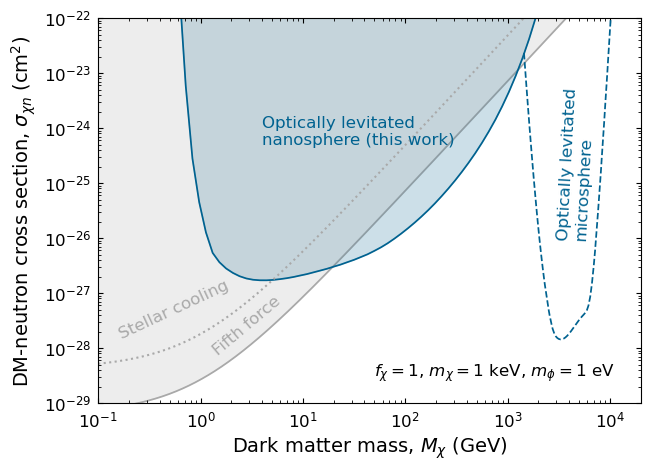

In [91]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

mx_fine = np.logspace(1, 8, 5000)
mx_list_coarse = mxs_c[1]
alpha_lim_combined_dm_1ev = alpha_lims_cl[1]

mx_plot_gev = np.logspace(-1, 6, 2000)
mx_plot = mx_plot_gev * 1e9

mmx = 1000               # DM constituent mass (eV)
nx = mx_plot / mmx       # Number of DM constituent      
mphi = 1

yn_lim_nanosphere_1ev = 4 * np.pi * alpha_lim_combined_dm_1ev
sigman_lim_nanosphere_1ev = get_sphere_sigma_n(mx_list_coarse*1e9, mphi, yn_lim_nanosphere_1ev)
sigman_lim_nanosphere_1ev_fine = np.interp(mx_fine, mx_list_coarse, sigman_lim_nanosphere_1ev)

yn_lim_usphere_1ev = 4 * np.pi * alpha_lim_usphere_1ev
sigman_lim_usphere_1ev = get_sphere_sigma_n(mx_fine*1e9, mphi, yn_lim_usphere_1ev)
sigman_lim_usphere_1ev = get_masked_usphere_lim(sigman_lim_usphere_1ev, sigman_lim_nanosphere_1ev_fine)

sigman_lim_fifth_force_1ev = get_fifth_force_sigma_n(mx_plot, mphi, lim='fifth_force', yx_lim='unity', Nx=nx)

ax.loglog(mx_list_coarse, sigman_lim_nanosphere_1ev, linewidth=1.25, color=colors[1])
ax.loglog(mx_fine, sigman_lim_usphere_1ev, '--', linewidth=1.25, color=colors[1])
ax.fill_between(mx_list_coarse, sigman_lim_nanosphere_1ev, 1e-20, color=colors[1], alpha=0.2)

ax.loglog(mx_plot_gev, sigman_lim_fifth_force_1ev, linewidth=1.25, zorder=-5, color='darkgrey')
ax.fill_between(mx_plot_gev, sigman_lim_fifth_force_1ev, 1e-20, color='darkgrey', alpha=0.2)

ax.loglog(mx_plot_gev, get_fifth_force_sigma_n(mx_plot, mphi, 'stellar_cooling', 'unity', nx), ':', linewidth=1.5, color='darkgrey')

# ax.loglog(mx_plot/1e9, get_dm_xsec(mx_plot/1e9, mmx/1e9, 5000e-9, 130, 3/0.05, 1000, np.pi * 1e7), label='XENON1T 1000 kg-yr', linewidth=1)
# ax.loglog(mx_plot/1e9, get_dm_xsec(mx_plot/1e9, mmx/1e9, 500e-9, 73, 10/0.05, 0.2, np.pi * 1e7), label='CDMSlite 0.2 kg-yr', linewidth=1)

ax.text(1.25, 7.5e-29, 'Fifth force', color='darkgrey', rotation=40, fontsize=12)
ax.text(0.15, 1.5e-28, 'Stellar cooling', color='darkgrey', rotation=25, fontsize=12)

ax.text(4, 5e-25, 'Optically levitated\nnanosphere (this work)', color=colors[1], rotation=0, fontsize=12)
ax.text(3e3, 1e-26, 'Optically levitated\nmicrosphere', color=colors[1], rotation=87, fontsize=12)

ax.set_xlabel(r'Dark matter mass, $M_\chi$ (GeV)', fontsize=14)
ax.set_ylabel(r'DM-neutron cross section, $\sigma_{\chi n}$ ($\mathrm{cm}^2$)', fontsize=14)

ax.text(5e1, 3e-29, fr'$f_\chi=1$, $m_\chi=1$ keV, $m_\phi={int(mphi)}$ eV', fontsize=12)

ax.set_xlim(1e-1, 2e4)
ax.set_ylim(1e-29, 1e-22)

ax.tick_params(right=True, top=True, labelright=False, labeltop=False, labelrotation=0)
ax.tick_params(axis='both', which='both', direction="in", pad=5, labelsize=12)

# plt.savefig('../paper_plots/composite_dm_limits.png', dpi=600, transparent=True)
plt.savefig('../paper_plots/composite_dm_limits.pdf', dpi=600)